### Иимпорт нужных библиотек

In [1]:
import torch
import numpy as np
import torch.nn as nn
import torchvision
import torch.optim as optim
import matplotlib.pyplot as plt

from torchinfo import summary
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, random_split
from IPython.display import clear_output

### Используем доступное устройство: GPU(CUDA), если видеокарта - NVIDIA, иначе - CPU

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### Создаём трансформер, чтобы сразу переводить данные в тензоры + нормализовывать их

In [3]:
transformer = transforms.Compose([
    transforms.ToTensor()
])

### Загружаем данные, делим трейн на трейн и валидацию, используем Dataloader, чтобы подавать данные батчами

In [4]:
TRAIN_SIZE = 40000
VALIDATION_SIZE = 10000
BATCH_SIZE = 128

train_data_transform = torchvision.datasets.CIFAR100(root='cifar', train=True, download=True,transform=transformer)
test_data_transofrm = torchvision.datasets.CIFAR100(root='cifar', train=False, download=True,transform=transformer)
train_subset_transform, eval_subset_transform = random_split(train_data_transform, [TRAIN_SIZE, VALIDATION_SIZE])

train_data = torchvision.datasets.CIFAR100(root='cifar', train=True, download=True)

train_loader = DataLoader(train_subset_transform, BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(eval_subset_transform, BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data_transofrm, BATCH_SIZE, shuffle=False)

### Создадим класс EarlyStoping

In [5]:
# Класс, предназначенный для предотвращения переобучения с сохранением параметров системы
class EarlyStopping:
    def __init__(self,path, patience=7, verbose=False, delta=0):
        self.patience = patience    
        self.verbose = verbose      
        self.counter = 0           
        self.best_score = None      
        self.early_stop = False     
        self.val_loss_min = np.inf  
        self.delta = delta          
        self.path = path           

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

### Итоговая Лосс Функция будет представлена как MSE + KLD
* `KLD`(Расстояние Кульбака Лейблера): $D_{KL}(N(\mu, \sigma^2) \parallel N(0, 1)) = \frac{1}{2} \sum \left( \sigma^2 + \mu^2 - 1 - \ln(\sigma^2) \right)$
* `KLD` отвечает за упаковку данных в нормальное распределение в центре координат
* `MSE` отвечает за декодирование изображения таким образом, чтобы оно было схоже с оригиналом
* Коэффициент `B` будет отвечать за баланс в задаче между `MSE/KDL`, то есть между центрированностью и схожестью с исходным изображением

In [6]:
def vae_loss_function(recon_x, x, mu, logvar, beta=0.1):
    # Ошибка восстановления(MSE)
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    
    # Расстояние Кульбака-Лейблера(KDL)
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Итоговый лосс с учётом коэффицента B
    total_loss = recon_loss + beta * kld_loss
    
    # Возвращаем средние значения по батчу
    batch_size = x.size(0)
    return total_loss / batch_size, recon_loss / batch_size, kld_loss / batch_size

### Функция обучения

In [7]:
def train(model, optimizer,scheduler,epochs=10):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        for batch_idx, (images, _) in enumerate(train_loader): 
            images = images.to(device)
            
            optimizer.zero_grad()     
            outputs, mu, logvar = model(images)
            
            loss, recon, kld = vae_loss_function(outputs, images, mu, logvar, beta=0.1)
            loss.backward()            
            optimizer.step()           
            
            train_loss += loss.item()
        
        model.eval()
        val_loss = 0
        
        with torch.no_grad(): 
            for images, _ in validation_loader: 
                images = images.to(device)
                outputs, mu, logvar = model(images)
            
                loss, recon, kld = vae_loss_function(outputs, images, mu, logvar, beta=0.1)
                
                val_loss += loss.item()
        
        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg = val_loss / len(validation_loader)
        
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        
        clear_output(wait=True)
        plt.figure(figsize=(6, 5))
        
        plt.plot(history['train_loss'], label='Train Loss')
        plt.plot(history['val_loss'], label='Val Loss')
        plt.title(f'Epoch {epoch+1} Reconstruction Loss (MSE)')
        plt.legend()
        plt.show()

        scheduler.step(val_loss_avg)
        early_stopping(val_loss_avg, model)
        
        print(f"Epoch {epoch+1}: Train Loss {train_loss_avg:.4f}, Val Loss {val_loss_avg:.4f}")

        if early_stopping.early_stop:
            print("Ранняя остановка")
            model.load_state_dict(torch.load('ae.pth'))
            break

### Создаём архитектуру автоэнкодера

In [8]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels)
        )
        self.relu = nn.LeakyReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.conv(x))

class VAE(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        
        # Энкодер
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            ResBlock(64),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            ResBlock(128),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(),
            ResBlock(256)
        )

        # Сбор Вероятностных параметров
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)
        
        # Декодер
        self.fc_dec = nn.Linear(latent_dim, 256 * 4 * 4)
        self.unflatten = nn.Unflatten(1, (256, 4, 4))
        
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            ResBlock(128),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            ResBlock(64),
            nn.ConvTranspose2d(64, 3, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    # Функция Репараметризации это способ сделать случайный выбор дифференцируемым.
    # Для этого делим вектор на 2 части: 1 - предсказанные параметры сетью mu, logvar; 2 - шум e, взятый из стандартного распределения независимый от сети
    # И Далее масштабируем этот шум с помощью параметров сети mu, logvar
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Сжатие
        x = self.encoder_conv(x)
        x = self.flatten(x)

        # Вероятностное описание
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)

        # Восстановление
        x = self.fc_dec(z)
        x = self.unflatten(x)
        reconstruction = self.decoder_conv(x)
        
        return reconstruction, mu, logvar

In [9]:
model = VAE()
model.to(device)
optimizer = optim.Adam(model.parameters(), lr = 0.001,weight_decay=1e-5)
# Scheduler используем для понижения LR, когда модель выходит на плато
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.1, 
    patience=5
)
summary(model, input_size=(BATCH_SIZE,3,32,32))

Layer (type:depth-idx)                   Output Shape              Param #
VAE                                      [128, 3, 32, 32]          --
├─Sequential: 1-1                        [128, 256, 4, 4]          --
│    └─Conv2d: 2-1                       [128, 64, 16, 16]         1,792
│    └─BatchNorm2d: 2-2                  [128, 64, 16, 16]         128
│    └─LeakyReLU: 2-3                    [128, 64, 16, 16]         --
│    └─ResBlock: 2-4                     [128, 64, 16, 16]         --
│    │    └─Sequential: 3-1              [128, 64, 16, 16]         73,984
│    │    └─LeakyReLU: 3-2               [128, 64, 16, 16]         --
│    └─Conv2d: 2-5                       [128, 128, 8, 8]          73,856
│    └─BatchNorm2d: 2-6                  [128, 128, 8, 8]          256
│    └─LeakyReLU: 2-7                    [128, 128, 8, 8]          --
│    └─ResBlock: 2-8                     [128, 128, 8, 8]          --
│    │    └─Sequential: 3-3              [128, 128, 8, 8]          295,4

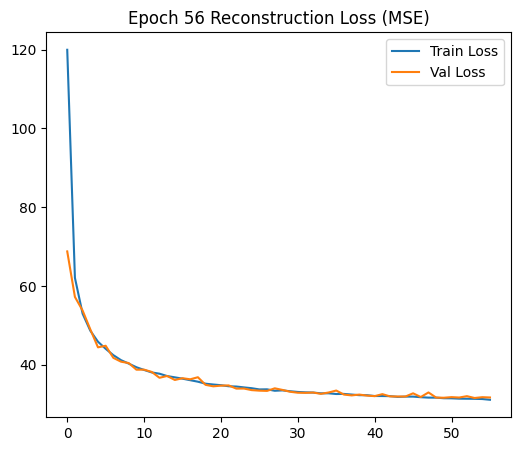

Epoch 56: Train Loss 31.1533, Val Loss 31.7349
Ранняя остановка


In [10]:
history = {'train_loss': [], 'val_loss': []}
early_stopping = EarlyStopping('vae1.pth',patience=7,verbose=True,delta=0.2)
train(model,optimizer,scheduler,epochs=200)

### Визуализация изображений оригинальных и после автоэнкодера

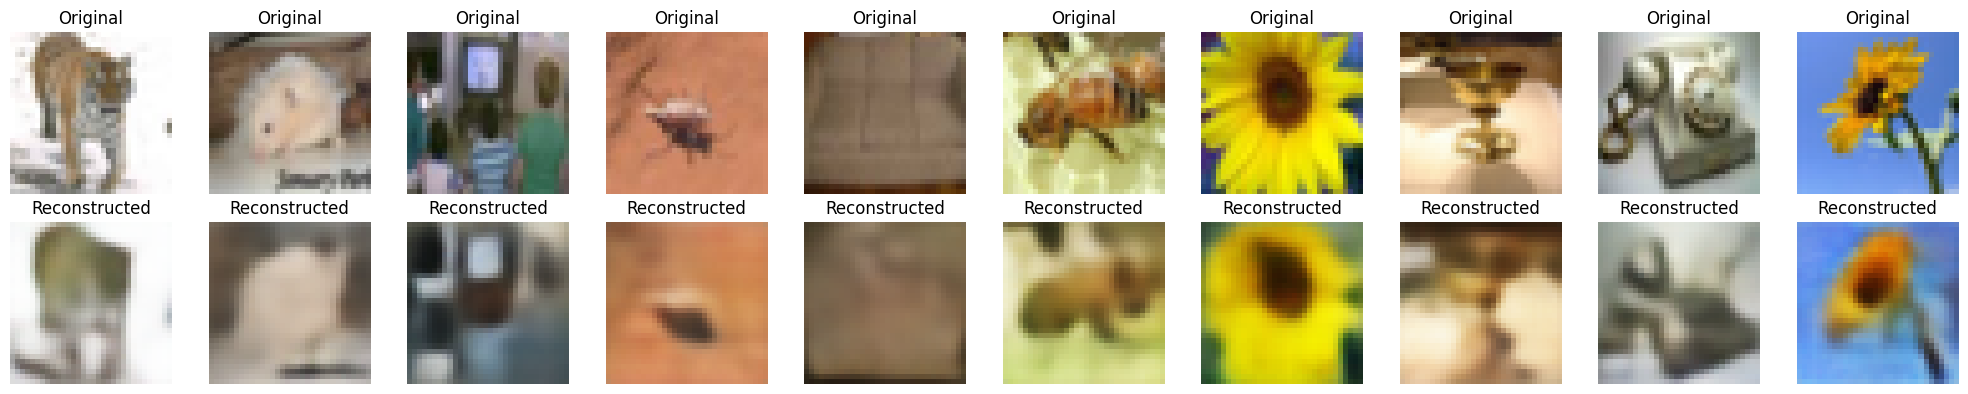

In [12]:
model.load_state_dict(torch.load('vae1.pth')) # Загружаем параметры модели, сохраненные EarlyStopiing
def visualize_reconstruction(model, dataloader, n_images=10):
    model.eval()
    images, _ = next(iter(dataloader))
    images = images.to(device)
    
    with torch.no_grad():
        # Распаковываем, забираем изображения остальное игнорируем
        reconstructed, _, _ = model(images) 
    
    images = images.cpu()
    reconstructed = reconstructed.cpu()
    
    plt.figure(figsize=(n_images * 2, 4))
    
    for i in range(n_images):
        img_orig = images[i].permute(1, 2, 0)
        
        ax = plt.subplot(2, n_images, i + 1)
        plt.imshow(img_orig)
        plt.title("Original")
        plt.axis("off")
        
        img_reconst = reconstructed[i].permute(1, 2, 0)
        
        ax = plt.subplot(2, n_images, i + 1 + n_images)
        plt.imshow(img_reconst)
        plt.title("Reconstructed")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

visualize_reconstruction(model, validation_loader)

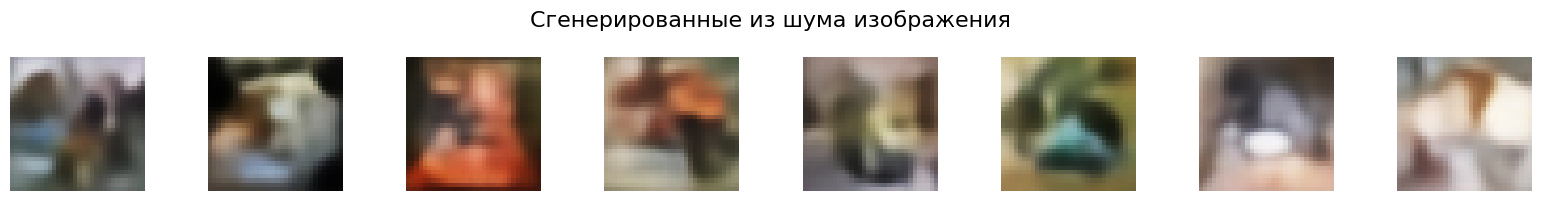

In [14]:
model.load_state_dict(torch.load('vae1.pth')) # Загружаем параметры модели, сохраненные EarlyStopiing
def generate_new_images(model, n_images=10, latent_dim=256, device='cuda'):
    model.eval() 
    
    # Берем случайный шум из N(0, 1)
    z = torch.randn(n_images, latent_dim).to(device)
    
    with torch.no_grad():
        # Пропускаем шум только через слои декодера
        x = model.fc_dec(z)
        x = model.unflatten(x)
        generated_images = model.decoder_conv(x)
        
    generated_images = generated_images.cpu()
    
    plt.figure(figsize=(n_images * 2, 2))
    for i in range(n_images):
        img = generated_images[i].permute(1, 2, 0) 
        
        ax = plt.subplot(1, n_images, i + 1)
        plt.imshow(img)
        plt.axis("off")
        
    plt.suptitle("Сгенерированные из шума изображения", fontsize=16)
    plt.tight_layout()
    plt.show()

generate_new_images(model, n_images=8, latent_dim=256, device=device)

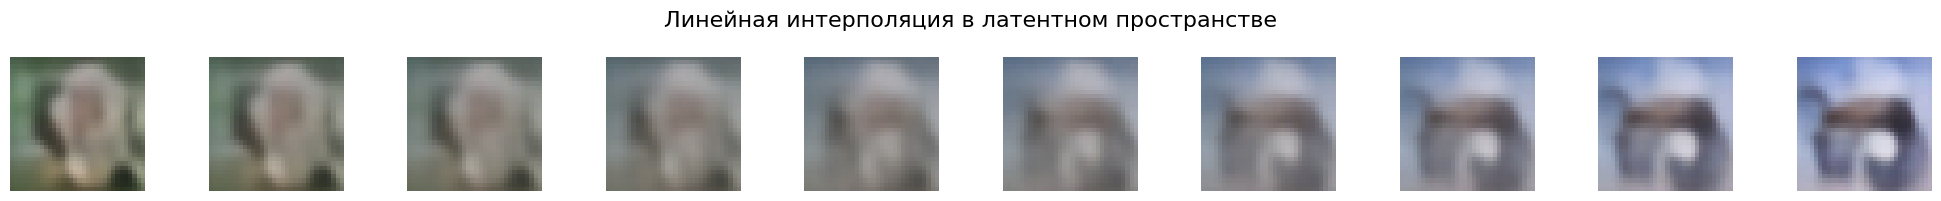

In [22]:
model.load_state_dict(torch.load('vae1.pth')) # Загружаем параметры модели, сохраненные EarlyStopiing
def interpolate_latent_space(model, n_steps=10, latent_dim=256, device='cuda'):
    model.eval()
    
    # Генерируем две случайные точки в латентном пространстве
    z1 = torch.randn(1, latent_dim).to(device)
    z2 = torch.randn(1, latent_dim).to(device)
    
    alpha_values = torch.linspace(0, 1, n_steps).to(device)
    
    interpolated_images = []
    
    with torch.no_grad():
        for alpha in alpha_values:
            # Линейная интерполяция между векторами
            z = z1 * (1 - alpha) + z2 * alpha
            
            # Пропускаем через декодер
            x = model.fc_dec(z)
            x = model.unflatten(x)
            generated = model.decoder_conv(x)
            interpolated_images.append(generated.cpu())
            
    plt.figure(figsize=(n_steps * 2, 2))
    for i in range(n_steps):
        img = interpolated_images[i][0].permute(1, 2, 0)
        
        plt.subplot(1, n_steps, i + 1)
        plt.imshow(img)
        plt.axis("off")
        
    plt.suptitle("Линейная интерполяция в латентном пространстве", fontsize=16)
    plt.tight_layout()
    plt.show()

interpolate_latent_space(model, n_steps=10, latent_dim=256, device=device)

### Выводы по использованию VAE:
* Можно увидеть, что у нас удалось получить не совсем чёткое, но изображение по которому явно можно понять, что там изображено.
* В сгенерированных шумом изображениях явно подтверждается гипотеза того, что VAE в отличие от AE это генеративная модель, взяв случайный шум, мы смогли получить изображение.
* И не менее интересный момент это линейная интерполяция, взяв 2 точки в латентном пространстве и выполняя линейную интерполяцию между ними, можно видеть как 1 изображение превращается в другое, похожее на него.

### Выбор архитектуры:
* Использование ResBlock позволяет строить более глубокие сети без затухания градиентов и лучше извлекать сложные признаки из изображений.
* Баланс через $\beta$: Использование коэффициента `b=0.1` в функции потерь позволило сместить акцент на качество восстановления (MSE), не давая штрафу за структуру пространства (KLD) слишком сильно размыть детали.(В ТЗ говорят, что хорошо бы получить изображения похожие на исходные,а не шум, поэтому выбор пал на `b=0.1`).